#### pandas 활용 데이터 전처리 & 시각화
- 외부프로그램 활용 : flourish
- 내부시각화 라이브러리 | 모듈
  - matplotlib : 코드 학습이 꽤 난이도가 있는 편 // 오래됨
  - seaborn : matplotlib를 활용해서 만든 그래프에 색상 및 레이아웃, 프레임 등을 조작
  - matplotlib + seaborn
  - plotly : 현존하는 파이썬 데이터 시각화의 가장 최신 트랜드
  - EDA + pandas + plotly : 해당 조합이 가장 최신 데이터 시각화 조합

#### plotly
1) Plotly Express : px (*빠르고 간단한 시각화)
   - 정말 짧은 코드로 괜찮은 시각적 그래프 출력
   - 학습속도 / EDA
   - 범례 / 2차원 다양한 종류 그래프 / 편집.가공
   - 디테일한 레이아웃 수정, 변경, 커스터마이징 x
2) Graph Objects : go (*세밀한 커스터마이징 필요)
   - 코드의 길이가 길어짐 / 초심자에게는 어려움
   - 애니메이션, 인터랙티브한 레이블 설정

In [1]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from plotly import express as px

"""
fig = px.그래프종류(
    데이터프레임,
    x="x축 열이름",
    y="y축 열이름",
    title="그래프제목"
)

fig.show() # 그래프를 화면에 출력하는 명령어

1) scatter (*산점도)

2) line (*선)

3) bar (*막대)

4) histogram (*히스토그램)

5) box (*상자그림)
"""

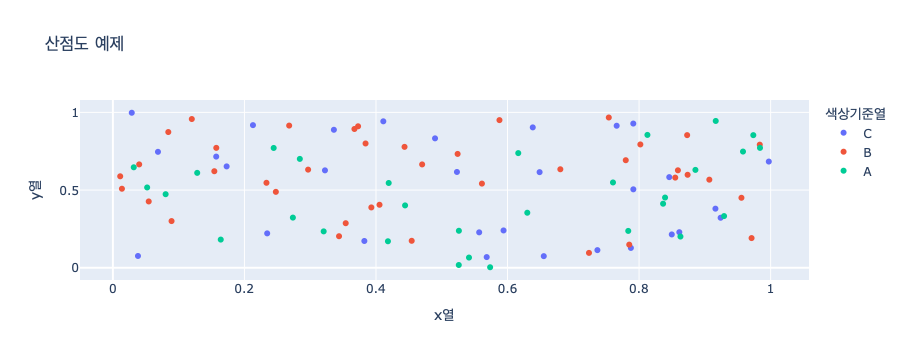

In [9]:
# 

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.random.rand(100), # 0 ~ 1미만의 실수자료형의 난수형태 값을 랜덤으로 생성
    "y열": np.random.rand(100), # 0 ~ 1미만의 실수자료형의 난수형태 값을 랜덤으로 생성
    "색상기준열": np.random.choice(["A", "B", "C"], 100), # 0 ~ 1미만의 실수자료형의 난수형태 값을 랜덤으로 생성
})

fig = px.scatter(
    df,
    x="x열",
    y="y열",
    color="색상기준열",
    title="산점도 예제"
)

fig.show()

#### 산점도 그래프 활용 방법
1) 관계분석 : 서로 다른 변수 사이에 상관관계가 존재하는지 파악하고 싶을 때
2) 패턴 및 경향성 파악 : 특정 데이터들이 어떤 패턴이나 경향성을 보이는지 확인하고자 할 때
3) 이상치(*Outlier) 탐지 : 전체 데이터에서 특정 데이터가 다른 값들과 동떨어진 좌표값 = 이상치을 가지고 있을 때, 식별
4) 탐색적 데이터 분석(*EDA) 초반 단계 : 전체 총 데이터안에 있는 feature들 간 상관관계 = 상호작용 여부를 판단하고자 할 때

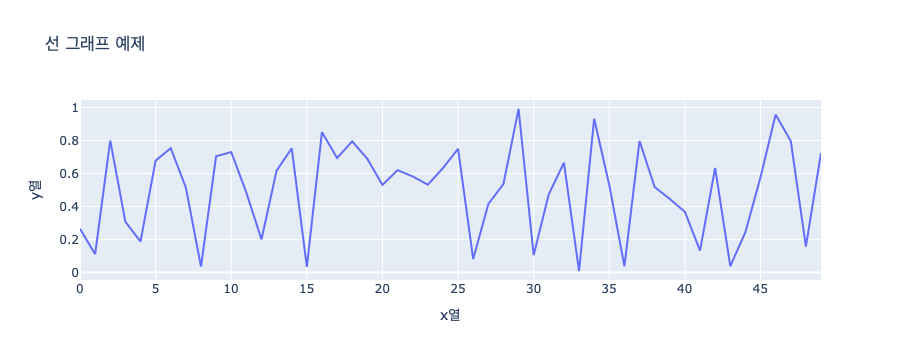

In [10]:
#

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.arange(50),
    "y열": np.random.rand(50)
})

fig = px.line(
    df,
    x = "x열",
    y = "y열",
    title = "선 그래프 예제"
)

fig.show()

In [14]:
# 선그래프 : 순차적인 순서에 따른 값의 변화를 선으로 연결해서 보고 싶을 때

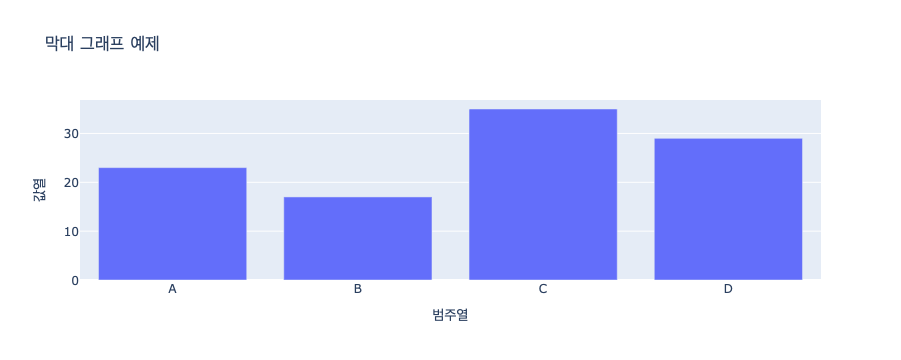

In [13]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "범주열": ["A", "B", "C", "D"],
    "값열": [23, 17, 35, 29]
})

fig = px.bar(
    df,
    x = "범주열",
    y = "값열",
    title = "막대 그래프 예제"
)

fig.show()

In [ ]:
# 범주별 = 범위별 막대의 높이로 비교해서 데이터를 분석 => m/s, 기간별 비교

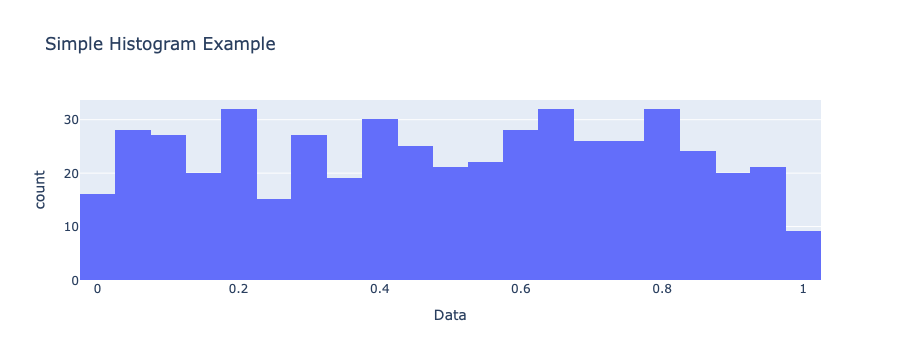

In [16]:
# 히스토그램 => 연속형 데이터의 분포를 구간별 막대로 나타내고자 할 때

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Data": np.random.rand(500)
})

fig = px.histogram(
    df,
    x="Data",
    nbins=30, # number of bins => bin => 구간 | 막대하나
    title="Simple Histogram Example"
)

fig.show()

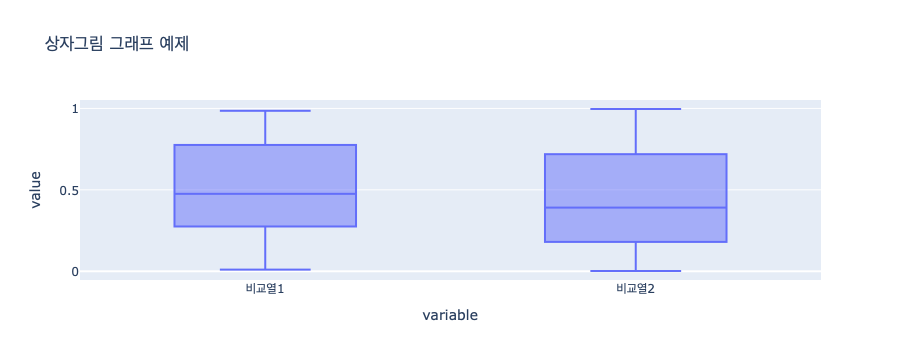

In [63]:
#

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "비교열1": np.random.rand(100),
    "비교열2": np.random.rand(100)
})

fig = px.box(
    df,
    y=["비교열1", "비교열2"],
    title="상자그림 그래프 예제"
)

fig.show()

#### 상자그림 그래프 (Box Plot)
- 여러개의 열의 데이터 분포, 중앙값, 사분위수 및 이상치를 한 눈에 확인 및 비교하고자 할 때 그래프
- 사분위수 계산 :
  Q1 : 데이터의 하위 25%
  Q3 : 데이터의 상위 25%
  이상치 : 최저값 0% 미만, 최고값 100% 초과
  => 이상치 값을 계산하기 위한 공식
  => Q3 - Q1 = IQR = Interquartile Range = 사분위 범위
  => 하한 이상치 = Q1 - IQR x 1.5
  => 상한 이상치 = Q3 + IQR x 1.5
  => 하한보다 작은 값이 나왔거나, 혹은 상한보다 높은 값이 나왔다 => 특이점 발생
  => 해당 특이점으로부터 발견해야하는 인사이트, 도출해야하는 문제점

In [18]:
# 각 개별 그래프의 세부요소 변경!!!
# 옵션 => 정말 다양 // 업데이트 빈번
# 1) update_layout() : 해당 그래프에 대한 전체 레이아웃 수정 => 제목, 범례, 여백
# 2) update_xaxes() : x축에 해당되는 속성 요소 수정 => 제목, 글꼴, 눈금 등
# 3) update_yaxes() : y축에 해당되는 속성 요소 수정 => 제목, 글꼴, 눈금 등

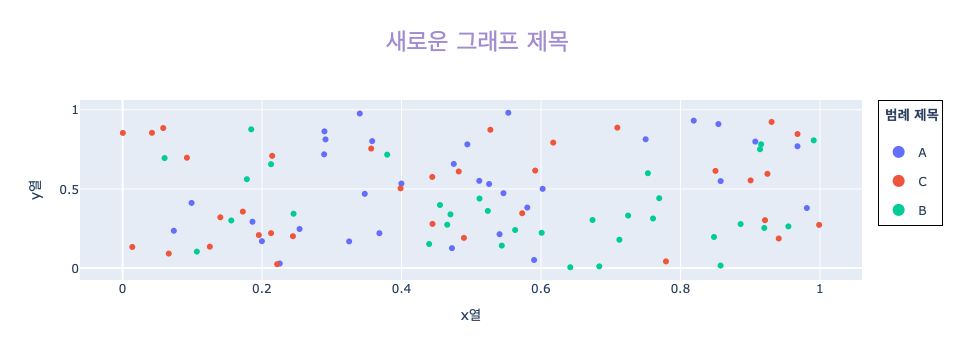

In [50]:
# 

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.random.rand(100), # 0 ~ 1미만의 실수자료형의 난수형태 값을 랜덤으로 생성
    "y열": np.random.rand(100), # 0 ~ 1미만의 실수자료형의 난수형태 값을 랜덤으로 생성
    "색상기준열": np.random.choice(["A", "B", "C"], 100), # 0 ~ 1미만의 실수자료형의 난수형태 값을 랜덤으로 생성
})

fig = px.scatter(
    df,
    x="x열",
    y="y열",
    color="색상기준열",
    title="산점도 예제"
)

fig.update_layout(
    title={
        "text": "새로운 그래프 제목",
        "font": {"size": 24, "color": "#a18cd1"},
        "x": 0.5
    },
    # legend={
    #     "title": "제목",
    #     "x": 1.02,
    #     "y": 1,
    #     "bordercolor": "#00f",
    #     "borderwidth": 1
    # }
    legend=dict(title=dict(
            text=" <b>범례 제목<b><br>  ",
            side="top"
        ), x=1.02, y=1, bordercolor="#000", xanchor="left", yanchor="top", borderwidth=1, itemsizing="constant", itemwidth=30, tracegroupgap=10)   # 기본보다 넓게 설정)
    # legend=dict(title="제목", bordercolor="black", xanchor="right", yanchor="top", borderwidth=1)
)

fig.show()

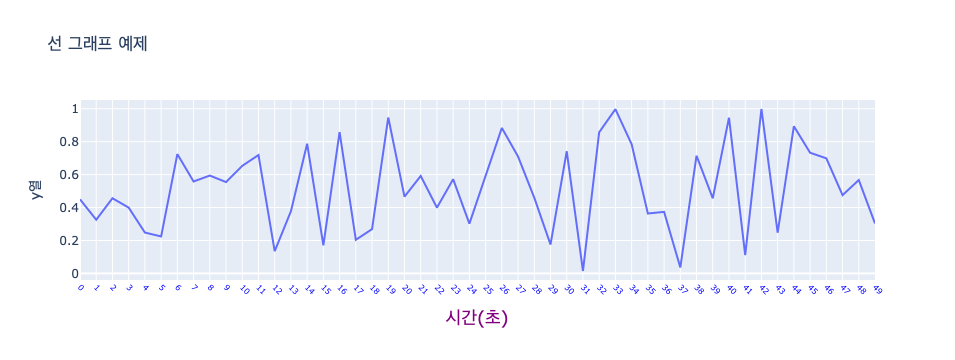

In [87]:
#

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.arange(50),
    "y열": np.random.rand(50)
})

fig = px.line(
    df,
    x = "x열",
    y = "y열",
    title = "선 그래프 예제"
)

fig.update_xaxes(
    title="시간(초)",
    # title_font={
    #     "size": 18,
    #     "color": "purple"
    # }
    title_font=dict(size=18, color="purple"),
    tickangle=45,
    # tickfont={
    #     "size":8
    # },
    tickfont=dict(size=8, color="#00f"),
    dtick=1
)

fig.show()

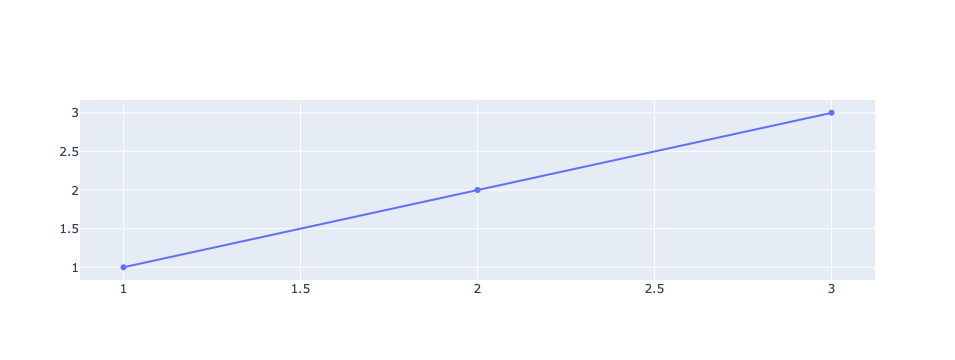

In [88]:
# import plotly.express as px # 관례적으로, 
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=[1, 2, 3],
        y=[1, 2, 3]
)

fig.update_layout(
    
)

fig.show()